# Lab: Generative Classifiers (LDA, QDA, Naive Bayes)

Based on the Chapter 4 lab . We predict whether the S&P 500 goes up or down using the
returns of the previous two days, with three generative classifiers. For each one we first use `scikit-learn`, then
recompute its predictions by hand from the formulas of the lecture.

Cells marked `# TODO` must be completed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.naive_bayes import GaussianNB as NB
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

## 1. The Smarket dataset

Daily percentage returns of the S&P 500 over 1250 days, from 2001 to 2005. For each day we have the returns of the
five previous days (`Lag1`-`Lag5`), the volume traded on the previous day (`Volume`, in billions), the return on
that day (`Today`) and the direction (`Direction`: `Up` if `Today` > 0).

In [2]:
Smarket = pd.read_csv("datasets/Smarket.csv")
print(Smarket.shape)
Smarket.head()

(1250, 9)


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


Correlations between today's return and the lags are all close to zero: predicting the market from past returns is
hard. The only clear pattern is that `Volume` grows with time.

In [3]:
Smarket.corr(numeric_only=True).round(3)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000,0.030,0.031,0.033,0.036,0.030,0.539,0.030
Lag1,0.030,1.000,-0.026,-0.011,-0.003,-0.006,0.041,-0.026
Lag2,0.031,-0.026,1.000,-0.026,-0.011,-0.004,-0.043,-0.010
Lag3,0.033,-0.011,-0.026,1.000,-0.024,-0.019,-0.042,-0.002
Lag4,0.036,-0.003,-0.011,-0.024,1.000,-0.027,-0.048,-0.007
Lag5,0.030,-0.006,-0.004,-0.019,-0.027,1.000,-0.022,-0.035
Volume,0.539,0.041,-0.043,-0.042,-0.048,-0.022,1.000,0.015
Today,0.030,-0.026,-0.010,-0.002,-0.007,-0.035,0.015,1.000


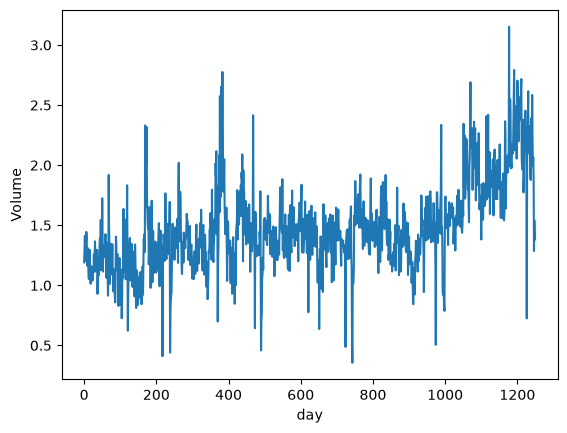

In [4]:
plt.plot(Smarket["Volume"])
plt.xlabel("day")
plt.ylabel("Volume")
plt.show()

## 2. Train and test sets

We train on 2001-2004 and test on 2005, which mimics using the model on days it has never seen. As in the logistic
regression part of the lab, we use only `Lag1` and `Lag2` as predictors. The response is $y = 1$ for `Up`.

Create `X_train`, `y_train`, `X_test`, `y_test` (`X` as `numpy` arrays with two columns, `y` as 0/1 arrays).

In [ ]:
features = ["Lag1", "Lag2"]
Smarket_train = Smarket.query("Year < 2005")
Smarket_2005 = Smarket.query("Year >= 2005")

# TODO
X_train = ...
y_train = ...
X_test = ...
y_test = ...

Before fitting anything: what accuracy does the trivial classifier "always predict `Up`" get on the test set? Every
model below should be compared with this number.

In [ ]:
# TODO

## 3. Linear Discriminant Analysis

### 3.1 With scikit-learn

`lda.predict()` returns the predicted class; `lda.predict_proba()` returns $\hat P(Y = k \mid x)$ for each class
(column 1 is `Up`). Fit LDA on the training set, then compute the test accuracy and the confusion matrix
(rows: true class, columns: predicted class).

In [ ]:
# TODO
lda = ...
lda_labels = ...
lda_prob = ...

The fitted parameters: priors $\hat\pi_k$, class means $\hat\mu_k$ and the shared covariance $\hat\Sigma$.

In [ ]:
# TODO: print priors_, means_, covariance_

- The mean of `Lag1` and `Lag2` is negative on `Up` days and positive on `Down` days. How would you describe this in
  words?
- The accuracy is the same as logistic regression with `Lag1 + Lag2` (0.56). Why are the two models so similar here?

### 3.2 By hand

Recompute LDA from the formulas of the lecture:

$$\hat\pi_k = \frac{n_k}{n}, \qquad \hat\mu_k = \frac{1}{n_k}\sum_{i: y_i = k} x_i, \qquad
\hat\Sigma = \frac{1}{n - K}\sum_{k}\sum_{i: y_i = k}(x_i - \hat\mu_k)(x_i - \hat\mu_k)^\top,$$

$$\delta_k(x) = \log \hat\pi_k - \tfrac12 \hat\mu_k^\top \hat\Sigma^{-1}\hat\mu_k + x^\top \hat\Sigma^{-1}\hat\mu_k,
\qquad \hat y = \arg\max_k \delta_k(x).$$

Compute `delta` (shape `(n_test, 2)`) and check that you get the same predictions as `scikit-learn`. Then recover
the probabilities with a softmax: $\hat P(Y = k \mid x) = e^{\delta_k(x)} / \sum_l e^{\delta_l(x)}$.

In [ ]:
n, K = len(y_train), 2
# TODO
pi_hat = ...
mu_hat = ...
Sigma_hat = ...

delta = ...
prob_by_hand = ...

`lda.covariance_` is slightly smaller than `Sigma_hat` because the stored attribute is divided by $n$ instead of
$n - K$, but the default solver predicts with the $n - K$ version: the probabilities agree to machine precision.

### 3.3 Threshold

`predict` uses $\hat P(\text{Up} \mid x) > 0.5$. Count how many test days have a predicted probability of `Up`
above 0.5, and the largest predicted probability over the whole test year. Then compute the accuracy for the
threshold 0.48.

In [ ]:
p_up = lda_prob[:, 1]
# TODO

- The posterior probabilities are all very close to 0.5. What does that say about how confident the model is?
- The threshold 0.48 improves the test accuracy. Should we report that number? (We chose it by looking at the test
  set: that is overfitting the test set. A threshold must be chosen on training or validation data.)

## 4. Quadratic Discriminant Analysis

### 4.1 With scikit-learn

Repeat the steps above with QDA. `store_covariance=True` keeps the covariance of each class in `qda.covariance_`.

In [ ]:
# TODO
qda = ...
qda_labels = ...
qda_prob = ...

QDA estimates $\hat\mu_k \in \mathbb{R}^2$ and $\hat\Sigma_k \in \mathbb{R}^{2 \times 2}$ for $k = 0, 1$.

In [ ]:
# TODO

### 4.2 By hand

$$\delta_k(x) = \log \hat\pi_k - \tfrac12 \log|\hat\Sigma_k| - \tfrac12 (x - \hat\mu_k)^\top \hat\Sigma_k^{-1}(x - \hat\mu_k),
\qquad \hat\Sigma_k = \frac{1}{n_k - 1}\sum_{i: y_i = k}(x_i - \hat\mu_k)(x_i - \hat\mu_k)^\top.$$

Hint: `np.cov(A, rowvar=False)` and `np.linalg.slogdet`.

In [ ]:
# TODO
Sigma_k = ...


def qda_delta(X, k):
    ...


delta_q = ...
prob_q = ...

- QDA reaches about 60% accuracy in 2005, better than LDA. Is that enough evidence that the boundary is really
  quadratic? What would you check before trusting it?

## 5. Naive Bayes

### 5.1 With scikit-learn

`GaussianNB` models each feature, inside each class, as an independent Gaussian. It stores the means in `theta_`
and the variances in `var_`.

In [ ]:
# TODO
nb = ...
nb_labels = ...
nb_prob = ...

### 5.2 By hand

With independent Gaussian features,

$$\delta_k(x) = \log \hat\pi_k - \frac12 \sum_{j=1}^p \left[\log(2\pi\hat\sigma_{kj}^2) + \frac{(x_j - \hat\mu_{kj})^2}{\hat\sigma_{kj}^2}\right],$$

where $\hat\sigma_{kj}^2$ is the variance of feature $j$ in class $k$ (`scikit-learn` divides by $n_k$).
Compare your variances with `nb.var_` and your probabilities with `nb_prob`.

In [ ]:
# TODO
var_hat = ...
delta_nb = ...
prob_nb = ...

- Compare `nb.var_` with the diagonal of `qda.covariance_`. What does Naive Bayes throw away compared to QDA?
- The correlation between `Lag1` and `Lag2` inside each class is very small (check it). What do you expect about
  the difference between QDA and Naive Bayes predictions?

In [ ]:
# TODO

## 6. Comparison

### 6.1 Decision boundaries

Plot $\hat P(\text{Up} \mid x)$ of each model on a grid of $(\text{Lag1}, \text{Lag2})$, together with the boundary
$\hat P = 0.5$ and the training points.

In [ ]:
models = {"LDA": lda, "QDA": qda, "Naive Bayes": nb}
g1, g2 = np.meshgrid(np.linspace(-5, 6, 200), np.linspace(-5, 6, 200))
grid = np.c_[g1.ravel(), g2.ravel()]

# TODO: one subplot per model with contourf of P(Up | x), the 0.5 contour and the training points

### 6.2 Accuracy and ROC

Build a table with the test accuracy and the AUC of each model, and plot their ROC curves on the test set.

In [ ]:
rows = []
# TODO

- All AUCs are close to 0.56. What does that say about these predictors, independently of the model?
- QDA and Naive Bayes have almost the same boundary. Use the lecture to explain why.
- The test year has 252 days. Is a difference of one or two percentage points in accuracy meaningful?

## 7. To go further

- Refit the three models with all the lags and `Volume`. Does anything improve?
- `src/models.py` implements the three classifiers as classes. Run `pytest tests` and `python main.py`.